# Data extraction

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from typing import List
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

## Old Data

In [2]:
df_active = pd.read_csv("dataset_active_mini.csv")
df_inactive = pd.read_csv("dataset_inactive_mini.csv")

# Separate active chat into normal and ack
df_active_normal = df_active[df_active['content'] != "[Control Message]\\nConfirmation ACK sent."]
df_active_ack = df_active[df_active['content'] == "[Control Message]\\nConfirmation ACK sent."]

# Drop unused columns from each dataset
df_active_normal = df_active_normal.drop(['ack1', 'ack3', 'id'], axis=1)
df_active_normal = df_active_normal.rename(columns={'hash': 'hash', 'content': 'content', 'ack0': 'ack0_normal', 'ack2': 'ack2_normal', 'memory': 'memory_normal'})
df_active_ack = df_active_ack.drop(['ack0', 'ack2', 'ack3', 'content', 'id'], axis=1)
df_active_ack = df_active_ack.rename(columns={'hash': 'hash', 'ack1': 'ack1_ack', 'memory': 'memory_ack'})
df_inactive = df_inactive.drop(['ack1', 'ack3', 'hash', 'id'], axis=1)
df_inactive = df_inactive.rename(columns={'content': 'content', 'ack0': 'ack0_inactive', 'ack2': 'ack2_inactive',  'memory': 'memory_inactive'})

# Treat missing values from all datasets
df_active_normal = df_active_normal.replace([np.inf, -np.inf], np.nan)
df_active_normal = df_active_normal.dropna()
df_active_ack = df_active_ack.replace([np.inf, -np.inf], np.nan)
df_active_ack = df_active_ack.dropna()
df_inactive = df_inactive.replace([np.inf, -np.inf], np.nan)
df_inactive = df_inactive.dropna()

# Get whats in common between hashes for active normal and ack
df_active = pd.merge(df_active_normal, df_active_ack, how='inner', on=['hash'])
# Get whats in common between content for active normal and inactive
df = pd.merge(df_active, df_inactive, how='inner', on=['content'])

# Drop outliers
df = df.drop((df[df['memory_inactive'] > 2500]).index, axis=0)

# Reindex
new_index = [i for i in range(len(df))]
df.index = new_index

df

,hash,content,ack0_normal,ack2_normal,memory_normal,ack1_ack,memory_ack,ack0_inactive,ack2_inactive,memory_inactive
0,81421e0343063dff82a9a1d69f20e7b191f25797efcedc...,C6b41EuLEdKVJg6CEEqciumOMevPNTnbcwvCKqmPbHssR1...,1.761559e+12,1.761559e+12,2943.0,1.761559e+12,724.0,1761562541746,1.761563e+12,1371
1,c9ea981a8db4cf69588a714c50f580b5fcc5c9658b6f48...,3d6zCDnX8PdVz0F722CAmrMrSnITXPl7cDcSwy5WYhZ7aD...,1.761559e+12,1.761559e+12,2943.0,1.761559e+12,724.0,1761562546538,1.761563e+12,1355
2,90a74316da3e7a228a8fe4f3d55e661b7c3bf8d1d5c65f...,YmsBmV5GHy7ANnZOcBSqqmwfaQHgltrJPxVz9JtlUobi9N...,1.761560e+12,1.761560e+12,3023.0,1.761560e+12,724.0,1761562551533,1.761563e+12,1435
3,b9cd4ce133b0cd78f7e868bff1af268e2f18714d2aecf2...,qcgFqEQDyBAcbQ3IMJd f7oZV5K4lQr64gYycQDM2As2Pj...,1.761559e+12,1.761559e+12,2943.0,1.761559e+12,724.0,1761562556538,1.761563e+12,1387
4,d3a2c1d04132f23f4ac019aa5c24e48c5365b28307835d...,uaTG TLFPEh2os4UnhyTCAYpz U36XumcM6iGaNYv 1Vjg...,1.761559e+12,1.761559e+12,2831.0,1.761559e+12,724.0,1761562611538,1.761563e+12,1273
...,...,...,...,...,...,...,...,...,...,...
56,915c7bb6873fbbec356a52beb7905b35edf8c1164421f6...,e7bQyW4GEoiHWFbE7OnvA39blc86C5LitPiyJQVKZtjW8v...,1.761559e+12,1.761559e+12,2943.0,1.761559e+12,740.0,1761563001538,1.761563e+12,1385
57,48829e14895f2e3bee2f49e34ed60d18e80f18fd5cfa27...,DN234bKnDRoPvxjI31JSF0RWqpN36oPiCTNWcgX8amw9sM,1.761559e+12,1.761559e+12,2831.0,1.761559e+12,724.0,1761563011534,1.761563e+12,1273
58,31fe5a77eadde1dc71093277c6ba73c0d9e0bcb0478307...,1ixvMgMgESrs5dDfmqQoHopsc9r2rpuai,1.761559e+12,1.761559e+12,2751.0,1.761559e+12,740.0,1761563026539,1.761563e+12,1190
59,e4819c7040ee7fa752f43c57e316c7425e92766b19406f...,RmLTb3Mc4eNRL7vTFwxs5PT,1.761559e+12,1.761559e+12,2719.0,1.761559e+12,740.0,1761563031540,1.761563e+12,1157


## New Data

In [9]:
def treat_active(main_path: str, secondary_path: str):
    df_active = pd.read_csv(main_path)

    # Drop unused rows (acks) from each dataset
    ack_rows = df_active[df_active['content'] == "[Control Message]\nConfirmation ACK sent."].index
    df_active = df_active.drop(ack_rows)

    # convert timestamp for preprocessing
    df_active['ack0'] = pd.to_datetime(df_active['ack0'], utc=True)
    df_active['ack1'] = pd.to_datetime(df_active['ack1'], utc=True)
    df_active['ack2'] = pd.to_datetime(df_active['ack2'], utc=True)

    # Drop unused columns from each dataset
    df_active = df_active.drop(['id', 'hash'], axis=1)
    df_active = df_active.rename(columns={'content': 'content', 'ack0': 'ack0_active', 'ack1': 'ack1_active', 'ack2': 'ack2_active', 'memory': 'memory_active'})

    logs = pd.read_csv(secondary_path)
    logs = logs.drop(columns=["level", "id"])
    logs["timestamp"] = pd.to_datetime(logs["timestamp"], utc=True)
    logs = logs.sort_values("timestamp")

    content_series = df_active['content']
    window = pd.Timedelta(seconds=2)

    EXPECTED = {
        "ack0_active": "Message generated. Started calculating metadata.",
        "ack1_active": "Sending message:",
    }

    for idx, row in df_active.iterrows():
        content = row["content"]

        ref_rows = logs.loc[logs["content"] == content, "timestamp"]
        if ref_rows.empty:
            raise ValueError(
                f"Reference content '{content}' not found in logs (df_active idx={idx})"
            )

        ref_ts = ref_rows.iloc[0]

        results = logs.loc[
            (logs["timestamp"] >= ref_ts - window) &
            (logs["timestamp"] <= ref_ts)
        ]

        for col, msg in EXPECTED.items():
            matches = results.loc[results["content"] == msg, "timestamp"]

            if matches.empty:
                raise ValueError(
                    f"Missing '{msg}' within 2s window for content '{content}' "
                    f"(df_active idx={idx}, ref_ts={ref_ts})"
                )

            df_active.loc[idx, col] = matches.iloc[0]

    # Convert back to ease relative metrics
    df_active['ack0_active'] = df_active['ack0_active'].map(pd.Timestamp.timestamp)*1000
    df_active['ack1_active'] = df_active['ack1_active'].map(pd.Timestamp.timestamp)*1000
    df_active['ack2_active'] = df_active['ack2_active'].map(pd.Timestamp.timestamp)*1000
    
    # Treat missing values from all datasets
    df_active = df_active.replace([np.inf, -np.inf], np.nan)
    #df_active = df_active.dropna() # commented because memory collection is wrong

    # derive times
    df_active["hashing_time"] = df_active['ack1_active'] - df_active['ack0_active']
    df_active["processing_time_active"] = df_active['ack2_active'] - df_active['ack0_active']
    
    return df_active

def treat_inactive(path: str):
    df_inactive = pd.read_csv(path)

    # Convert timestamps
    df_inactive['ack1'] = pd.to_datetime(df_inactive['ack1'], utc=True)
    df_inactive['ack2'] = pd.to_datetime(df_inactive['ack2'], utc=True)
    df_inactive['ack1'] = df_inactive['ack1'].map(pd.Timestamp.timestamp)*1000
    df_inactive['ack2'] = df_inactive['ack2'].map(pd.Timestamp.timestamp)*1000

    # Drop unused columns from each dataset
    df_inactive = df_inactive.drop(['ack0', 'id', 'hash'], axis=1)
    df_inactive = df_inactive.rename(columns={'content': 'content', 'ack1': 'ack1_inactive', 'ack2': 'ack2_inactive', 'memory': 'memory_inactive'})

    # Treat missing values from all datasets
    df_inactive = df_inactive.replace([np.inf, -np.inf], np.nan)
    # df_inactive = df_inactive.dropna()

    # derive times
    df_inactive["processing_time_inactive"] = df_inactive['ack2_inactive'] - df_inactive['ack1_inactive']
    
    return df_inactive

df_active = treat_active(f"data/last/active/whatsapp-data-4.csv", f"data/last/active/logs-times-4.csv")
df_inactive = treat_inactive(f"data/last/inactive/whatsapp-data-4.csv")
df_inactive.describe(), df_active.describe()

(       ack1_inactive  ack2_inactive  memory_inactive  processing_time_inactive
 count   2.500000e+01   2.500000e+01              0.0                 25.000000
 mean    1.767119e+12   1.767119e+12              NaN                  9.200000
 std     7.359775e+04   7.359736e+04              NaN                  2.179449
 min     1.767119e+12   1.767119e+12              NaN                  6.000000
 25%     1.767119e+12   1.767119e+12              NaN                  8.000000
 50%     1.767119e+12   1.767119e+12              NaN                  9.000000
 75%     1.767119e+12   1.767119e+12              NaN                 10.000000
 max     1.767119e+12   1.767119e+12              NaN                 14.000000,
         ack0_active   ack1_active   ack2_active  memory_active  hashing_time  \
 count  2.500000e+01  2.500000e+01  2.500000e+01            0.0     25.000000   
 mean   1.766264e+12  1.766264e+12  1.766264e+12            NaN     22.800000   
 std    7.359844e+04  7.359839e+04  

In [2]:
def treat_active(main_path: str, secondary_path: str):
    df_active = pd.read_csv(main_path)

    # Drop unused rows (acks) from each dataset
    ack_rows = df_active[df_active['content'] == "[Control Message]\nConfirmation ACK sent."].index
    df_active = df_active.drop(ack_rows)

    # convert timestamp for preprocessing
    df_active['ack0'] = pd.to_datetime(df_active['ack0'], utc=True)
    df_active['ack1'] = pd.to_datetime(df_active['ack1'], utc=True)
    df_active['ack2'] = pd.to_datetime(df_active['ack2'], utc=True)

    # Drop unused columns from each dataset
    df_active = df_active.drop(['id', 'hash'], axis=1)
    df_active = df_active.rename(columns={'content': 'content', 'ack0': 'ack0_active', 'ack1': 'ack1_active', 'ack2': 'ack2_active', 'memory': 'memory_active'})

    logs = pd.read_csv(secondary_path)
    logs = logs.drop(columns=["level", "id"])
    logs["timestamp"] = pd.to_datetime(logs["timestamp"], utc=True)
    logs = logs.sort_values("timestamp")

    content_series = df_active['content']
    window = pd.Timedelta(seconds=2)

    EXPECTED = {
        "ack0_active": "Message generated. Started calculating metadata.",
        "ack1_active": "Sending message:",
    }

    for idx, row in df_active.iterrows():
        content = row["content"]

        ref_rows = logs.loc[logs["content"] == content, "timestamp"]
        if ref_rows.empty:
            raise ValueError(
                f"Reference content '{content}' not found in logs (df_active idx={idx})"
            )

        ref_ts = ref_rows.iloc[0]

        results = logs.loc[
            (logs["timestamp"] >= ref_ts - window) &
            (logs["timestamp"] <= ref_ts)
        ]

        for col, msg in EXPECTED.items():
            matches = results.loc[results["content"] == msg, "timestamp"]

            if matches.empty:
                raise ValueError(
                    f"Missing '{msg}' within 2s window for content '{content}' "
                    f"(df_active idx={idx}, ref_ts={ref_ts})"
                )

            df_active.loc[idx, col] = matches.iloc[0]

    # Convert back to ease relative metrics
    df_active['ack0_active'] = df_active['ack0_active'].map(pd.Timestamp.timestamp)*1000
    df_active['ack1_active'] = df_active['ack1_active'].map(pd.Timestamp.timestamp)*1000
    df_active['ack2_active'] = df_active['ack2_active'].map(pd.Timestamp.timestamp)*1000
    
    # Treat missing values from all datasets
    df_active = df_active.replace([np.inf, -np.inf], np.nan)
    #df_active = df_active.dropna() # commented because memory collection is wrong

    # derive times
    df_active["hashing_time"] = df_active['ack1_active'] - df_active['ack0_active']
    df_active["processing_time_active"] = df_active['ack2_active'] - df_active['ack0_active']
    
    return df_active

def treat_inactive(path: str):
    df_inactive = pd.read_csv(path)

    # Drop unused columns from each dataset
    df_inactive = df_inactive.drop(['ack1', 'ack3', 'id', 'hash'], axis=1)
    df_inactive = df_inactive.rename(columns={'content': 'content', 'ack0': 'ack0_inactive', 'ack2': 'ack2_inactive', 'ackpre': 'ackpre_inactive', 'memory': 'memory_inactive'})

    # Treat missing values from all datasets
    df_inactive = df_inactive.replace([np.inf, -np.inf], np.nan)
    df_inactive = df_inactive.dropna()
    
    return df_inactive

In [3]:
def treat_active_time(path: str):
    df_active = pd.read_csv(path)

    # Drop unused rows (acks) from each dataset
    ack_rows = df_active[df_active['content'] == "[Control Message]\nConfirmation ACK sent."].index
    df_active = df_active.drop(ack_rows)

    # Drop unused columns from each dataset
    df_active = df_active.drop(['ack1', 'ack2', 'ack3', 'id', 'hash', 'memory'], axis=1)
    df_active = df_active.rename(columns={'content': 'content', 'ack0': 'ack0_active', 'ackpre': 'ackpre_active'})

    # Treat missing values from all datasets
    df_active = df_active.replace([np.inf, -np.inf], np.nan)
    df_active = df_active.dropna()
    
    return df_active

def treat_inactive_time(path: str):
    df_inactive = pd.read_csv(path)

    # Drop unused columns from each dataset
    df_inactive = df_inactive.drop(['ack1', 'ack2', 'ack3', 'id', 'hash', 'memory'], axis=1)
    df_inactive = df_inactive.rename(columns={'content': 'content', 'ack0': 'ack0_inactive','ackpre': 'ackpre_inactive'})

    # Treat missing values from all datasets
    df_inactive = df_inactive.replace([np.inf, -np.inf], np.nan)
    df_inactive = df_inactive.dropna()
    
    return df_inactive

In [28]:
def aggregate_data(active_treat, inactive_treat):
    df_actives = []
    df_inactives = []

    for i in range(1, 7):
        df_actives.append(active_treat(f"new_dataset_active_{i}.csv"))
        df_inactives.append(inactive_treat(f"new_dataset_inactive_{i}.csv"))

    df_active = pd.concat(df_actives)
    df_inactive = pd.concat(df_inactives)

    df_active.index = range(0, len(df_active))
    df_inactive.index = range(0, len(df_inactive))

    return df_active, df_inactive

In [29]:
df_active, df_inactive = aggregate_data(treat_active, treat_inactive)
df_active

,content,hash,ackpre_active,ack0_active,ack2_active,memory_active
0,715b,6aef68945113fe5032ce9943d28aa25565bc17a2a9614b...,1.762459e+12,1.762459e+12,1.762459e+12,2736.0
1,kdDR,5359b37ded5ed4bce28cb0119eed8f8d548528aeecb3ee...,1.762459e+12,1.762459e+12,1.762459e+12,2752.0
2,CFF8,ba7464bd823b024aeed420dde3f882a6fc291f23b81ec9...,1.762459e+12,1.762459e+12,1.762459e+12,4871.0
3,iwHW,57e47faad1bff49b70812f45f556ebd9756837956e123b...,1.762459e+12,1.762459e+12,1.762459e+12,2736.0
4,WPV2,23ecc0678ca7b9857947e9296231696060ddabdd8f469a...,1.762459e+12,1.762459e+12,1.762459e+12,2720.0
5,usTH,1619843cd5f54f5418a6e11b0d567d7fabf0f5ee60486a...,1.762459e+12,1.762459e+12,1.762459e+12,2720.0
6,NSs0,906c24ff7804321215825255e72809303654f5de6b49c7...,1.762459e+12,1.762459e+12,1.762459e+12,2720.0
7,kyIR,95f7ecded0a1155ef4af35c675e6208d58fe1c51d9aa7c...,1.762459e+12,1.762459e+12,1.762459e+12,2736.0
8,0572FYQWoWJduGvH,864d7373108ca5e815014aa12120ebff669e40ffa6bdb5...,1.762459e+12,1.762459e+12,1.762459e+12,2768.0
9,3UbEAURTbRUr YA,691e4bc870fdd9fbbe5ebe713bed060f32a292f72a4f23...,1.762459e+12,1.762459e+12,1.762459e+12,2768.0


In [99]:
df_active, df_inactive = aggregate_data(treat_active_time, treat_inactive_time)
df_inactive

,content,ackpre_inactive,ack0_inactive
0,Xwm4,1762463610672,1762463610681
1,kyIR,1762463600672,1762463600678
2,5FE8,1762463550676,1762463550684
3,kdDR,1762463390675,1762463390682
4,do8W,1762463530676,1762463530682
...,...,...,...
145,YnnvpBhWeFiRfNZ5 FpQriBT4O7UxTX6BzYEHHBNXqiqAd...,1762466363864,1762466363870
146,BKBx6s8YpfqzrJw148bB47O8oK76JxfxAipRGBocTSLuYO...,1762466343864,1762466343870
147,7A4xtKhjqWQ6G8XMvIpQBu9rRGJxn4vm5gxPUQCWIYIaOl...,1762466423868,1762466423875
148,PPNXy oTuxtLtpA0Soo0LE0oX41k5F4JUqhvVwHtU2vIkD...,1762466383868,1762466383874


In [100]:
df_active['processing_time'] = df_active["ack0_active"] - df_active['ackpre_active']
df_inactive['processing_time'] = df_inactive["ack0_inactive"] - df_inactive['ackpre_inactive']
# df_active['transmition_time_active'] = df_active["ack2_active"] - df_active['ackpre_active']
# df_inactive['transmition_time_inactive'] = df_inactive["ack2_inactive"] - df_inactive['ackpre_inactive']
df_active['content_length'] = df_active['content'].apply(lambda x: len(x.encode("utf-8")))
df_inactive['content_length'] = df_inactive['content'].apply(lambda x: len(x.encode("utf-8")))
#df_active['processing_time_per_length'] = df_active["processing_time"]/df_active['content_length']
#df_inactive['processing_time_per_length'] = df_inactive["processing_time"]/df_inactive['content_length']

In [81]:
df_active['processing_time'].mean(), df_active['processing_time'].std()

(np.float64(124.71333333333334), np.float64(182.330231294341))

In [61]:
df_active.groupby(by='content_length')['processing_time'].min()

content_length
4       29.0
16      73.0
64      70.0
256     65.0
1024    75.0
4096    75.0
Name: processing_time, dtype: float64

In [62]:
df_active[df_active['content_length'] == 4].sort_values(by='processing_time', ascending=True)

,content,ackpre_active,ack0_active,processing_time,content_length
17,sIn3,1.762459e+12,1.762459e+12,29.0,4
9,bJNa,1.762459e+12,1.762459e+12,32.0,4
11,GZI5,1.762459e+12,1.762459e+12,34.0,4
13,TDt1,1.762459e+12,1.762459e+12,36.0,4
15,mpM2,1.762459e+12,1.762459e+12,39.0,4
1,715b,1.762459e+12,1.762459e+12,39.0,4
20,EPQf,1.762459e+12,1.762459e+12,73.0,4
12,NSs0,1.762459e+12,1.762459e+12,100.0,4
4,U2zS,1.762459e+12,1.762459e+12,101.0,4
18,5FE8,1.762459e+12,1.762459e+12,102.0,4


In [102]:
df_active[(df_active['processing_time'] > 400)]

,content,ackpre_active,ack0_active,processing_time,content_length
2,kdDR,1.762459e+12,1.762459e+12,678.0,4
3,CFF8,1.762459e+12,1.762459e+12,1623.0,4
5,iwHW,1.762459e+12,1.762459e+12,1384.0,4
21,rT7D,1.762459e+12,1.762459e+12,464.0,4
44,LxBFzCjsICKdmLtv,1.762459e+12,1.762459e+12,595.0,16


In [112]:
# treating active outliers (should have only one outlier around ten times the mean)

drop_items = df_active[(df_active['processing_time'] > 400)]
df_active = df_active.drop(drop_items.index)

In [113]:
df_active['processing_time'].mean(), df_active['processing_time'].std()

(np.float64(96.29655172413793), np.float64(50.22423664288142))

<Axes: >

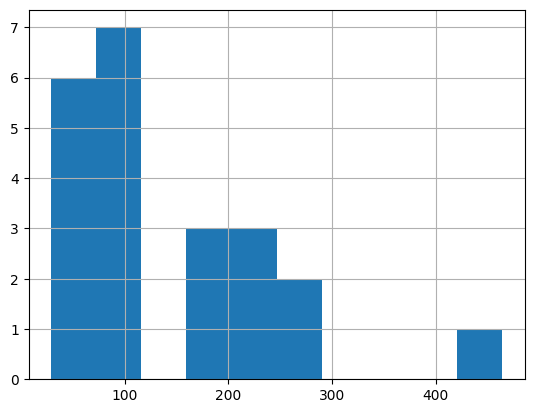

In [52]:
df_active[df_active['content_length'] == 4]['processing_time'].hist()

In [53]:
summary_active = (
    df_active.groupby("content_length")[['processing_time']]
      .agg(["mean", "std"])
)
summary_inactive = (
    df_inactive.groupby("content_length")[['processing_time']]
      .agg(["mean", "std"])
)
summary_active, summary_inactive

(               processing_time            
                           mean         std
 content_length                            
 4                   140.318182  106.456960
 16                  108.800000  104.275277
 64                   86.240000   44.208106
 256                  86.800000   41.974198
 1024                102.400000   50.869113
 4096                 93.160000   43.010348,
                processing_time           
                           mean        std
 content_length                           
 4                        16.64  46.751898
 16                       17.88  48.781246
 64                       16.48  39.343699
 256                      19.64  60.708237
 1024                     16.00  39.135449
 4096                     14.44  40.122811)

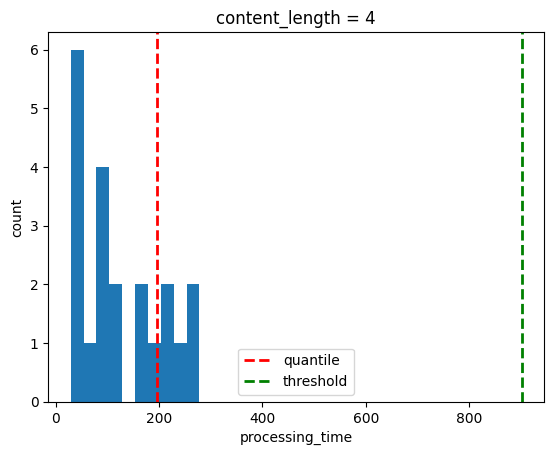

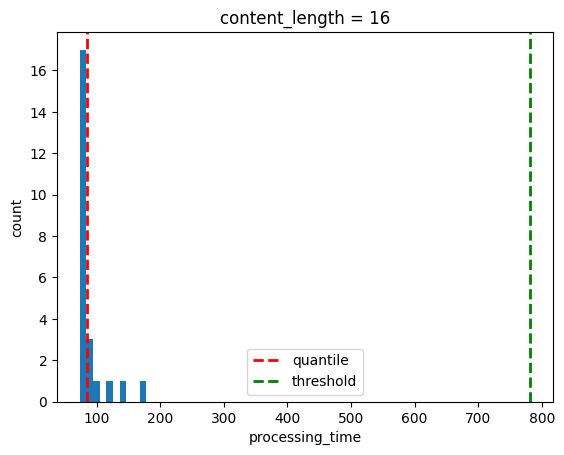

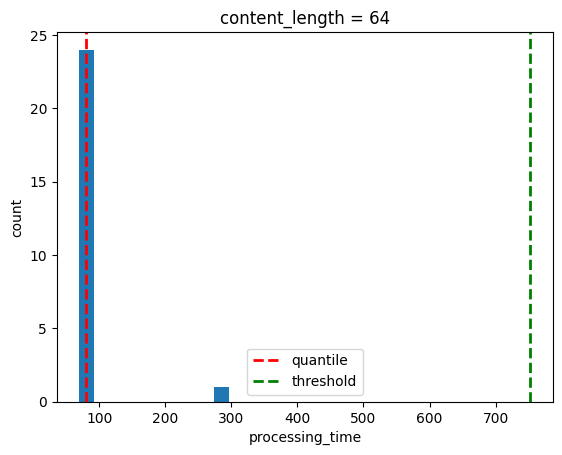

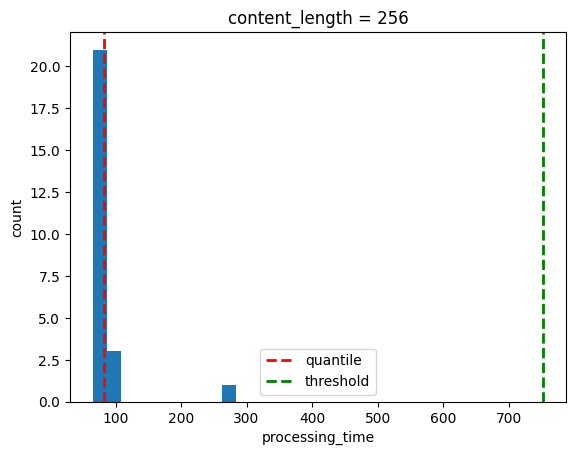

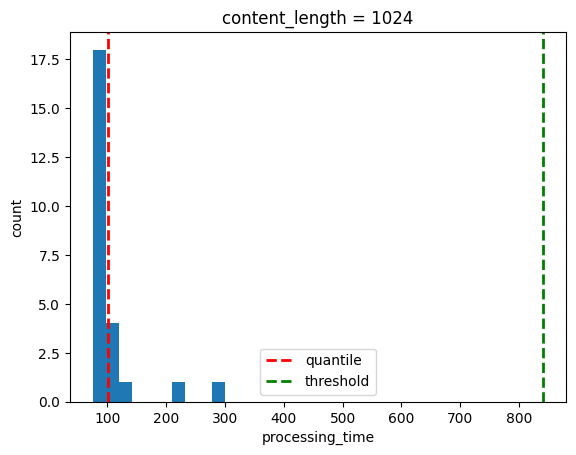

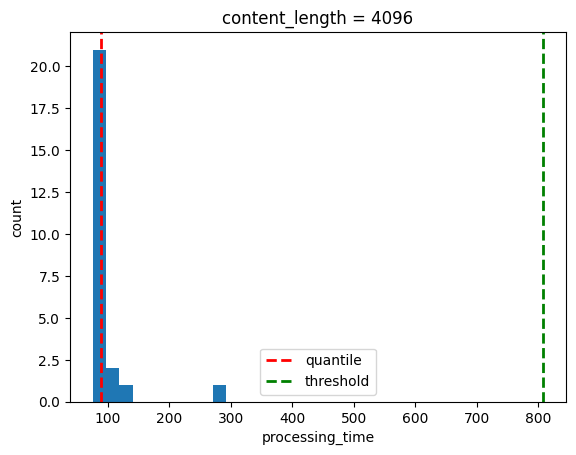

In [116]:
for content_length, group in df_active.groupby("content_length"):
    data = group["processing_time"]

    quantile = data.quantile(0.75)
    # kappa is fitted accordingly to the df_inactive distribution of processing time
    kappa = 10
    threshold = data[data <= quantile].mean()*kappa

    plt.figure()
    plt.hist(data, bins=10)
    plt.axvline(quantile, linestyle="--", c='r', linewidth=2, label='quantile')
    plt.axvline(threshold, linestyle="--", c='g', linewidth=2, label='threshold')

    plt.title(f"content_length = {content_length}")
    plt.xlabel("processing_time")
    plt.ylabel("count")
    plt.legend()

    plt.show()

In [42]:
df_active[df_active['content_length'] == 4].sort_values(by='processing_time_active', ascending=False).head()

,content,ackpre_active,ack0_active,processing_time_active,content_length
12,CFF8,1.762459e+12,1.762459e+12,1623.0,4
15,iwHW,1.762459e+12,1.762459e+12,1384.0,4
6,kdDR,1.762459e+12,1.762459e+12,678.0,4
39,rT7D,1.762459e+12,1.762459e+12,464.0,4
21,usTH,1.762459e+12,1.762459e+12,278.0,4


In [37]:
df_inactive[df_inactive['content_length'] == 4].sort_values(by='processing_time_inactive', ascending=False).head()

,content,ackpre_inactive,ack0_inactive,processing_time_inactive,content_length
14,ANze,1762463370672,1762463370913,241,4
13,bJNa,1762463460675,1762463460684,9,4
22,NSs0,1762463490675,1762463490684,9,4
0,Xwm4,1762463610672,1762463610681,9,4
2,5FE8,1762463550676,1762463550684,8,4


In [50]:
df_active_filtered = df_active[(df_active['processing_time_active'] < 1000) & (df_active['content_length'] == 4)]
df_inactive_filtered = df_inactive[(df_inactive['processing_time_inactive'] < 200) & (df_inactive['content_length'] == 4)]

In [51]:
summary_active = (
    df_active_filtered.groupby("content_length")[['processing_time_active']]
      .agg(["mean", "std"])
)
summary_inactive = (
    df_inactive_filtered.groupby("content_length")[['processing_time_inactive']]
      .agg(["mean", "std"])
)
summary_active, summary_inactive

(               processing_time_active        
                                  mean     std
 content_length                               
 4                          163.695652  152.93,
                processing_time_inactive          
                                    mean       std
 content_length                                   
 4                              7.291667  0.999094)

In [6]:
 2557.5 / 107.5

23.790697674418606

In [13]:
df['processing_time_active'] = df["ack0_active"] - df['ackpre_active']
df['processing_time_inactive'] = df["ack0_inactive"] - df['ackpre_inactive']
df['content_length'] = df['content'].apply(lambda x: len(x.encode("utf-8")))

KeyError: 'ack0_active'

In [ ]:
# Group by message length and compute mean and std
summary = (
    df.groupby("content_length")[["memory_active", "memory_inactive"]]
      .agg(["mean", "std"])
)

# Flatten multiindex columns
summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()

# Extract values
x = np.arange(len(summary["content_length"]))  # positions for groups
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# Plot bars with error bars (std)
ax.bar(x - width/2, summary["memory_active_mean"], width,
       yerr=summary["memory_active_std"], capsize=5, label="OnTR integrated Whatsapp")

ax.bar(x + width/2, summary["memory_inactive_mean"], width,
       yerr=summary["memory_inactive_std"], capsize=5, label="Vanilla Whatsapp")

# Labels and styling
ax.set_xlabel("Message size (bytes)", fontsize=12)
ax.set_ylabel("Space used (bytes)", fontsize=12)
ax.set_title("Memory comsumption", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(summary["content_length"])
ax.legend(frameon=False)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Tighter layout for publication
plt.tight_layout()
# plt.savefig("memory_consumption_2.png")
plt.show()

In [ ]:
summary['memory_increment'] = summary['memory_active_mean'] - summary['memory_inactive_mean']
summary['memory_increment'].describe()

In [12]:
df_without_outliers = df[df['processing_time_active'] < 1000]
summary = (
    df_without_outliers.groupby("content_length")[["processing_time_active", "processing_time_inactive"]]
      .agg(["mean", "std"])
)

# Flatten multiindex columns
summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()

# Extract values
x = np.arange(len(summary["content_length"]))  # positions for groups
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# Plot bars with error bars (std)
ax.bar(x - width/2, summary["processing_time_active_mean"], width,
       yerr=summary["processing_time_active_std"], capsize=5, label="OnTR integrated Whatsapp")

ax.bar(x + width/2, summary["processing_time_inactive_mean"], width,
       yerr=summary["processing_time_inactive_std"], capsize=5, label="Vanilla Whatsapp")

# Labels and styling
ax.set_xlabel("Message size (bytes)", fontsize=12)
ax.set_ylabel("Time (ms)", fontsize=12)
ax.set_title("Processing time", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(summary["content_length"])
ax.legend(frameon=False)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Tighter layout for publication
plt.tight_layout()
# plt.savefig("memory_consumption_2.png")
plt.show()

KeyError: 'processing_time_active'

In [9]:
df[['processing_time_active', 'processing_time_inactive']].describe()

KeyError: "None of [Index(['processing_time_active', 'processing_time_inactive'], dtype='object')] are in the [columns]"

In [20]:
124.598639 - 17.054422

107.544217

# Feature generation

# Insights Objectives
- Is the memory consumption correlated with the memory size (yes)

## Discoveries
- The correlation is so high that can be well approximated by an line
- The ack memory use is approximatly constant

## Memory
- How much more memory is used per char in active chats against inactive ones? (with and without ack)

In [5]:
df['total_memory_active'] = df['memory_normal'] + df['memory_ack']
df['total_memory_active']

0     3667.0
1     3667.0
2     3747.0
3     3667.0
4     3555.0
       ...  
56    3683.0
57    3555.0
58    3491.0
59    3459.0
60    3459.0
Name: total_memory_active, Length: 61, dtype: float64

In [6]:
df['content_length'] = df['content'].apply(lambda x: len(x.encode("utf-8")))
df

,hash,content,ack0_normal,ack2_normal,memory_normal,ack1_ack,memory_ack,ack0_inactive,ack2_inactive,memory_inactive,total_memory_active,content_length
0,81421e0343063dff82a9a1d69f20e7b191f25797efcedc...,C6b41EuLEdKVJg6CEEqciumOMevPNTnbcwvCKqmPbHssR1...,1.761559e+12,1.761559e+12,2943.0,1.761559e+12,724.0,1761562541746,1.761563e+12,1371,3667.0,76
1,c9ea981a8db4cf69588a714c50f580b5fcc5c9658b6f48...,3d6zCDnX8PdVz0F722CAmrMrSnITXPl7cDcSwy5WYhZ7aD...,1.761559e+12,1.761559e+12,2943.0,1.761559e+12,724.0,1761562546538,1.761563e+12,1355,3667.0,71
2,90a74316da3e7a228a8fe4f3d55e661b7c3bf8d1d5c65f...,YmsBmV5GHy7ANnZOcBSqqmwfaQHgltrJPxVz9JtlUobi9N...,1.761560e+12,1.761560e+12,3023.0,1.761560e+12,724.0,1761562551533,1.761563e+12,1435,3747.0,96
3,b9cd4ce133b0cd78f7e868bff1af268e2f18714d2aecf2...,qcgFqEQDyBAcbQ3IMJd f7oZV5K4lQr64gYycQDM2As2Pj...,1.761559e+12,1.761559e+12,2943.0,1.761559e+12,724.0,1761562556538,1.761563e+12,1387,3667.0,81
4,d3a2c1d04132f23f4ac019aa5c24e48c5365b28307835d...,uaTG TLFPEh2os4UnhyTCAYpz U36XumcM6iGaNYv 1Vjg...,1.761559e+12,1.761559e+12,2831.0,1.761559e+12,724.0,1761562611538,1.761563e+12,1273,3555.0,52
...,...,...,...,...,...,...,...,...,...,...,...,...
56,915c7bb6873fbbec356a52beb7905b35edf8c1164421f6...,e7bQyW4GEoiHWFbE7OnvA39blc86C5LitPiyJQVKZtjW8v...,1.761559e+12,1.761559e+12,2943.0,1.761559e+12,740.0,1761563001538,1.761563e+12,1385,3683.0,77
57,48829e14895f2e3bee2f49e34ed60d18e80f18fd5cfa27...,DN234bKnDRoPvxjI31JSF0RWqpN36oPiCTNWcgX8amw9sM,1.761559e+12,1.761559e+12,2831.0,1.761559e+12,724.0,1761563011534,1.761563e+12,1273,3555.0,46
58,31fe5a77eadde1dc71093277c6ba73c0d9e0bcb0478307...,1ixvMgMgESrs5dDfmqQoHopsc9r2rpuai,1.761559e+12,1.761559e+12,2751.0,1.761559e+12,740.0,1761563026539,1.761563e+12,1190,3491.0,33
59,e4819c7040ee7fa752f43c57e316c7425e92766b19406f...,RmLTb3Mc4eNRL7vTFwxs5PT,1.761559e+12,1.761559e+12,2719.0,1.761559e+12,740.0,1761563031540,1.761563e+12,1157,3459.0,23


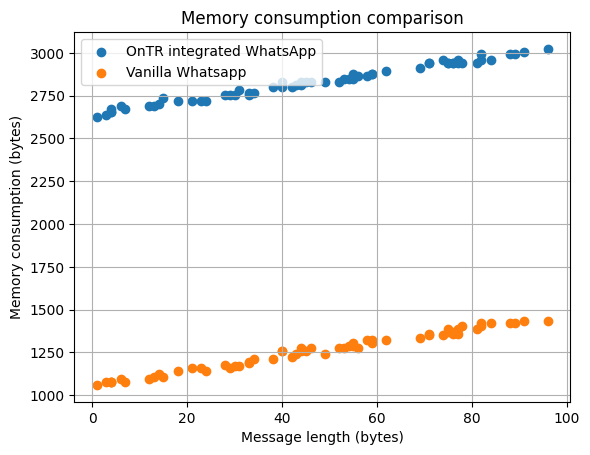

In [7]:
fig, ax1 = plt.subplots()

# First y-axis (left)
ax1.scatter(df['content_length'], df['memory_normal'], color='tab:blue', label='OnTR integrated WhatsApp')
ax1.set_xlabel("Message length (bytes)")
ax1.set_ylabel("Memory consumption (bytes)")

# Second y-axis (right)
# ax2 = ax1.twinx()
ax1.scatter(df['content_length'], df['memory_inactive'], color='tab:orange', label='Vanilla Whatsapp')

# Title
plt.title("Memory consumption comparison")

# Legends (combine both axes)
lines, labels = ax1.get_legend_handles_labels()
ax1.legend(loc='upper left')

plt.grid()

plt.savefig("memory_consumption.png")
plt.show()

In [8]:
# Prepare the data
X = df[['content_length']]  # Features
X = sm.add_constant(X)      # Adds intercept term (column of 1s)
y = df['memory_normal']

# Create and train the model
model = sm.OLS(y, X).fit()

# Get predictions
y_pred = model.predict(X)

# Extract coefficients
linear_coefficient_ontr = model.params['const']          # Intercept
angular_coefficient_ontr = model.params['content_length']  # Slope
variance_points_ontr = ((y - y_pred)**2)

# Calculate metrics
r2 = model.rsquared
mse = np.mean((y - y_pred)**2)
rmse = np.sqrt(mse)

# Print full statistical summary (includes variances, std errors, t-stats, etc.)
print("\n--- Statsmodels Summary ---")
print(model.summary())


--- Statsmodels Summary ---
                            OLS Regression Results                            
Dep. Variable:          memory_normal   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     4294.
Date:                Mon, 03 Nov 2025   Prob (F-statistic):           8.19e-57
Time:                        10:51:19   Log-Likelihood:                -241.10
No. Observations:                  61   AIC:                             486.2
Df Residuals:                      59   BIC:                             490.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          

In [9]:
# Prepare the data
X = df[['content_length']]  # Features
X = sm.add_constant(X)      # Adds intercept term (column of 1s)
y = df['memory_inactive']

# Create and train the model
model = sm.OLS(y, X).fit()

# Get predictions
y_pred = model.predict(X)

# Extract coefficients
linear_coefficient_vanilla = model.params['const']          # Intercept
angular_coefficient_vanilla = model.params['content_length']  # Slope
variance_points_vanilla = ((y - y_pred)**2)

# Calculate metrics
r2 = model.rsquared
mse = np.mean((y - y_pred)**2)
rmse = np.sqrt(mse)

# Print results
print(f"Linear coefficient (intercept): {linear_coefficient_vanilla}")
print(f"Angular coefficient (slope): {angular_coefficient_vanilla}")
print(f"Equation: memory = {angular_coefficient_vanilla:.4f} * content_length + {linear_coefficient_vanilla:.4f}")
print(f"\nTraining Accuracy (R²): {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MSE: {mse:.4f}")

# Print full statistical summary (includes variances, std errors, t-stats, etc.)
print("\n--- Statsmodels Summary ---")
print(model.summary())

Linear coefficient (intercept): 1059.4225809880463
Angular coefficient (slope): 4.155970466550011
Equation: memory = 4.1560 * content_length + 1059.4226

Training Accuracy (R²): 0.9852
RMSE: 13.6814
MSE: 187.1801

--- Statsmodels Summary ---
                            OLS Regression Results                            
Dep. Variable:        memory_inactive   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     3937.
Date:                Mon, 03 Nov 2025   Prob (F-statistic):           1.03e-55
Time:                        10:51:19   Log-Likelihood:                -246.13
No. Observations:                  61   AIC:                             496.3
Df Residuals:                      59   BIC:                             500.5
Df Model:                           1                                         
Covariance Type:            nonrobust          

In [13]:
linear_coefficient_vanilla_err = 3.611
linear_coefficient_ontr_err = 3.325

ratio = linear_coefficient_ontr / linear_coefficient_vanilla
#ratio_err = 
linear_coefficient_ontr, linear_coefficient_vanilla

(np.float64(2640.931808147047), np.float64(1059.4225809880463))

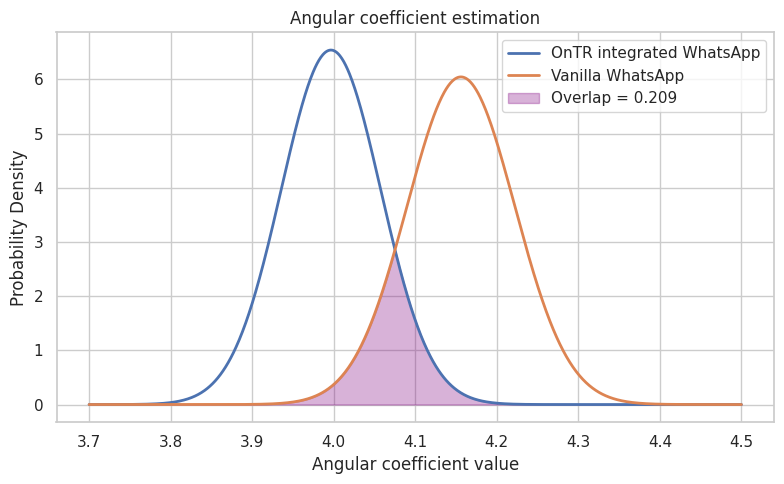

Overlap area (probability distributions similarity): 0.2092


In [10]:
import scipy as sci

sns.set_theme(style="whitegrid")

# Parameters for two Gaussians
mean_ontr, std_ontr = 3.9966, 0.061       # Gaussian 1
mean_vanilla, std_vanilla = 4.1560, 0.066 # Gaussian 2

# Generate x range that covers both
x = np.linspace(3.7, 4.5, 1000)

# Compute Gaussian (normal) PDFs
y_ontr = sci.stats.norm.pdf(x, loc=mean_ontr, scale=std_ontr)
y_vanilla = sci.stats.norm.pdf(x, loc=mean_vanilla, scale=std_vanilla)

# Compute overlap region (pointwise minimum)
y_overlap = np.minimum(y_ontr, y_vanilla)

# Integrate overlap area using Simpson’s rule
overlap_area = sci.integrate.simpson(y_overlap, x)

# Plot
plt.figure(figsize=(8,5))
plt.plot(x, y_ontr, label=f"OnTR integrated WhatsApp", linewidth=2)
plt.plot(x, y_vanilla, label=f"Vanilla WhatsApp", linewidth=2)
plt.fill_between(x, y_overlap, color='purple', alpha=0.3, label=f"Overlap = {overlap_area:.3f}")

plt.title("Angular coefficient estimation")
plt.xlabel("Angular coefficient value")
plt.ylabel("Probability Density")
plt.legend(loc='best')
plt.tight_layout()
plt.show()

print(f"Overlap area (probability distributions similarity): {overlap_area:.4f}")

(<Axes: >,
 count    61.000000
 mean      4.287589
 std       1.984170
 min       0.643936
 25%       3.795455
 50%       3.965503
 75%       4.223738
 max      17.931808
 Name: memory_per_char_normal, dtype: float64)

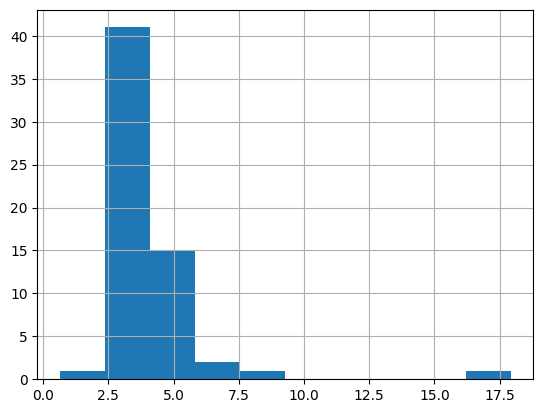

In [57]:
df['memory_per_char_normal'] = abs((df['memory_normal'] - linear_coefficient) / df['content_length'])
df['memory_per_char_normal'].hist(), df['memory_per_char_normal'].describe()

In [10]:
df[df['memory_per_char_normal'] > 15]
# df[df['content_length'] < 5]

,hash,content,ack0_normal,ack2_normal,memory_normal,ack1_ack,memory_ack,ack0_inactive,ack2_inactive,memory_inactive,total_memory_active,content_length,memory_per_char_normal
34,4284988906cb419d3bf2122b3dea3e2abdc96b54c6424e...,L,1.761560e+12,1.761560e+12,2623.0,1.761560e+12,740.0,1761562851536,1.761563e+12,1060,3363.0,1,17.931808


In [11]:
# Prepare the data
X = df[['content_length']].values  # Features (2D array)
y = df['memory_inactive'].values  # Target (1D array)

# Create and train the model
model = LinearRegression()
model.fit(X, y)

# Get predictions
y_pred = model.predict(X)

# Get coefficients
angular_coefficient = model.coef_[0]  # Slope
linear_coefficient = model.intercept_  # Intercept

# Calculate training accuracy metrics
r2 = r2_score(y, y_pred)  # R² score (coefficient of determination)
mse = mean_squared_error(y, y_pred)  # Mean squared error
rmse = np.sqrt(mse)  # Root mean squared error

# Print results
print(f"Linear coefficient (intercept): {linear_coefficient}")
print(f"Angular coefficient (slope): {angular_coefficient}")
print(f"Equation: memory = {angular_coefficient:.4f} * content_length + {linear_coefficient:.4f}")
print(f"\nTraining Accuracy (R²): {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MSE: {mse:.4f}")

Linear coefficient (intercept): 1059.4225809880459
Angular coefficient (slope): 4.155970466550015
Equation: memory = 4.1560 * content_length + 1059.4226

Training Accuracy (R²): 0.9852
RMSE: 13.6814
MSE: 187.1801


(<Axes: >,
 count    61.000000
 mean      4.085959
 std       0.683627
 min       0.577419
 25%       3.942320
 50%       4.144355
 75%       4.390609
 max       5.525806
 Name: memory_per_char_inactive, dtype: float64)

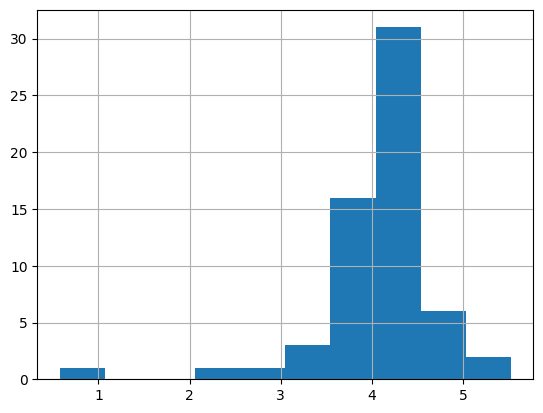

In [12]:
df['memory_per_char_inactive'] = abs((df['memory_inactive'] - linear_coefficient) / df['content_length'])
df['memory_per_char_inactive'].hist(), df['memory_per_char_inactive'].describe()

<Axes: >

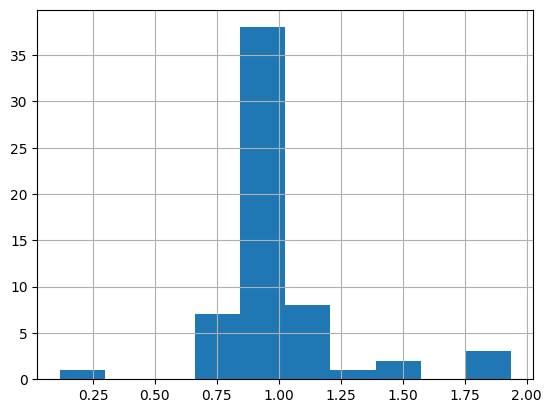

In [40]:
df['char_augmentation_ratio_normal'] = df['memory_per_char_normal'] / df['memory_per_char_inactive']
df_without_outlier = df[df['char_augmentation_ratio_normal'] < 20]
df_without_outlier['char_augmentation_ratio_normal'].hist()


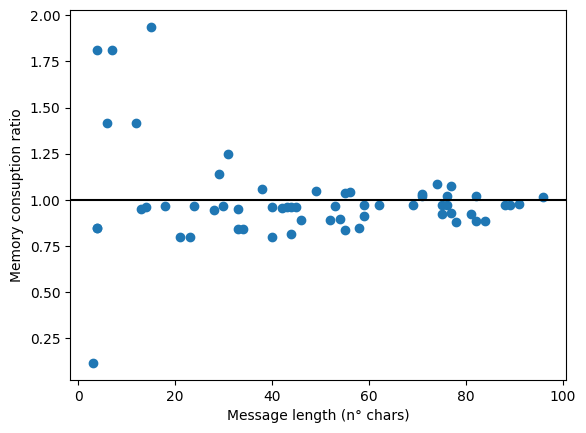

In [46]:
plt.scatter(df_without_outlier['content_length'], df_without_outlier['char_augmentation_ratio_normal'])
plt.xlabel("Message length (n° chars)")
plt.ylabel("Memory consuption ratio")
plt.axhline(y=1, c='k')

### Velocity

In [14]:
df['delay_normal'] = df['ack2_normal'] - df['ack0_normal']
df['delay_inactive'] = df['ack2_inactive'] - df['ack0_inactive']
df[['delay_normal', 'delay_inactive']].describe()

,delay_normal,delay_inactive
count,61.000000,61.000000
mean,2550.163934,7594.688525
std,380.878860,8939.860721
min,2010.000000,2016.000000
25%,2218.000000,4064.000000
50%,2533.000000,4840.000000
75%,2809.000000,6701.000000
max,3411.000000,48435.000000


[[ 1.        -0.0428261]
 [-0.0428261  1.       ]]


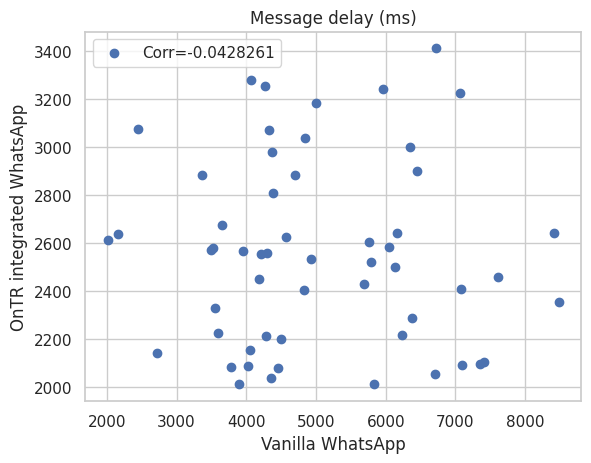

In [18]:
df_without_outlier = df[df['delay_inactive'] < 12000]
plt.scatter(df_without_outlier['delay_inactive'], df_without_outlier['delay_normal'], label="Corr=-0.0428261")
plt.xlabel("Vanilla WhatsApp")
plt.ylabel("OnTR integrated WhatsApp")
plt.title("Message delay (ms)")
plt.legend()
print(np.corrcoef(df_without_outlier['delay_inactive'], df_without_outlier['delay_normal']))

plt.savefig("delays.png")

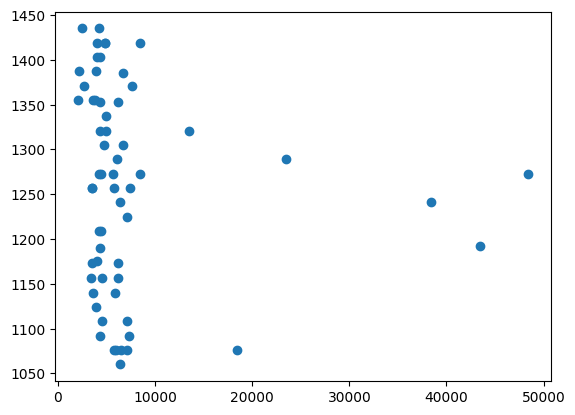

In [35]:
plt.scatter(df['delay_inactive'], df['memory_inactive'])